<a href="https://colab.research.google.com/github/muhammad-usman-tech/data-analysis-tasks/blob/main/lab_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

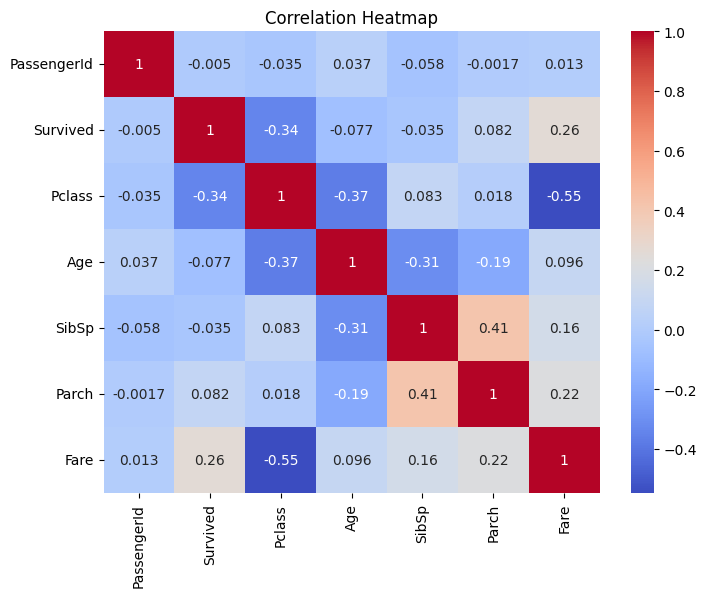

LEVEL 1 — Overall Survival Rate:
38.4%

LEVEL 2 — Survival by Class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64

LEVEL 3 — Survival by Class AND Gender:
Pclass  Sex   
1       female    96.8
        male      36.9
2       female    92.1
        male      15.7
3       female    50.0
        male      13.5
Name: Survived, dtype: float64

LEVEL 4 — Survival by Class, Gender AND Age Group:
Pclass  Sex     Age_Group  
1       female  Child           90.9
                Young Adult     97.2
                Middle Age      97.2
                Senior         100.0
        male    Child           80.0
                Young Adult     50.0
                Middle Age      37.0
                Senior           8.3
2       female  Child          100.0
                Young Adult     92.5
                Middle Age      85.0
                Senior           NaN
        male    Child           60.0
                Young Adult      7.4
                Middle Age       3.7
   

/tmp/ipykernel_12430/2748528347.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['Pclass','Sex','Age_Group'])['Survived'].mean().mul(100).round(1))


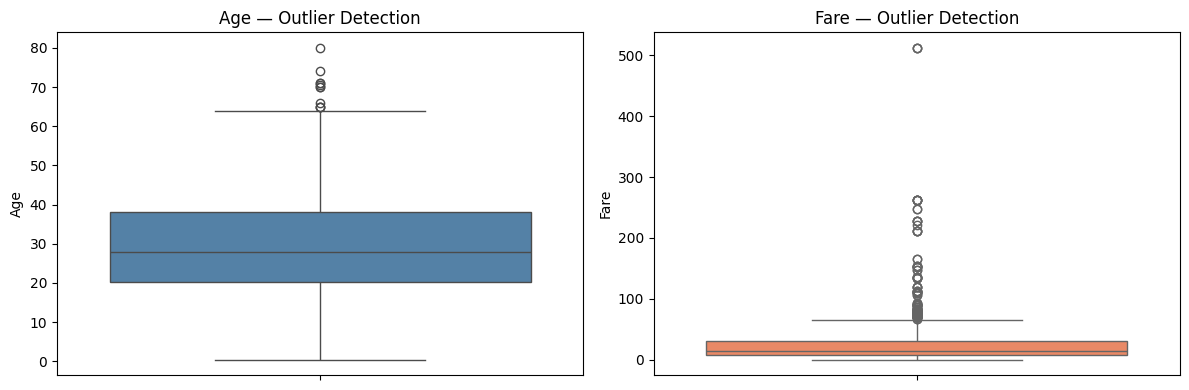


Z-SCORE METHOD:
Age outliers (Z>3): 7
                                     Name   Age  Age_Zscore
96              Goldschmidt, Mr. George B  71.0    3.178283
116                  Connors, Mr. Patrick  70.5    3.139805
493               Artagaveytia, Mr. Ramon  71.0    3.178283
630  Barkworth, Mr. Algernon Henry Wilson  80.0    3.870872
672           Mitchell, Mr. Henry Michael  70.0    3.101328

Fare outliers (Z>3): 20
                                                Name      Fare  Fare_Zscore
27                    Fortune, Mr. Charles Alexander  263.0000     4.647001
88                        Fortune, Miss. Mabel Helen  263.0000     4.647001
118                         Baxter, Mr. Quigg Edmond  247.5208     4.335332
258                                 Ward, Miss. Anna  512.3292     9.667167
299  Baxter, Mrs. James (Helene DeLaudeniere Chaput)  247.5208     4.335332

IQR METHOD:

Age IQR Analysis:
Q1: 20.125, Q3: 38.0, IQR: 17.875
Lower limit: -6.6875, Upper limit: 64.8125
Outliers fo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df=pd.read_csv('Titanic-Dataset.csv')
df.head()
# df.shape
# df.info()
df.isnull().sum()
# df.describe()
df=df.drop(columns='Cabin')

corr = df.corr(numeric_only=True)
corr
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

from scipy import stats

# =====================
# STEP 5 — DATA DRILLING
# Topic: Data Drilling
# =====================

# First add Age Group column for drilling
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 35, 60, 100],
    labels=['Child', 'Young Adult', 'Middle Age', 'Senior']
)

# Level 1 — Overall survival rate
print("LEVEL 1 — Overall Survival Rate:")
print(f"{df['Survived'].mean()*100:.1f}%")

# Level 2 — Drill down by Class
print("\nLEVEL 2 — Survival by Class:")
print(df.groupby('Pclass')['Survived'].mean().mul(100).round(1))

# Level 3 — Drill down by Class AND Gender
print("\nLEVEL 3 — Survival by Class AND Gender:")
print(df.groupby(['Pclass','Sex'])['Survived'].mean().mul(100).round(1))

# Level 4 — Drill down by Class AND Gender AND Age Group
print("\nLEVEL 4 — Survival by Class, Gender AND Age Group:")
print(df.groupby(['Pclass','Sex','Age_Group'])['Survived'].mean().mul(100).round(1))

# Fare drilling
print("\nFARE DRILLING — By Class:")
print(df.groupby('Pclass')['Fare'].agg(['mean','median','min','max']).round(2))

print("\nFARE DRILLING — By Class AND Embarkation:")
print(df.groupby(['Pclass','Embarked'])['Fare'].mean().round(2))

# =====================
# STEP 6 — OUTLIER DETECTION
# Topic: Data Mining
# =====================

print("=" * 50)
print("OUTLIER DETECTION")
print("=" * 50)

# --- Method 1 — Box Plot ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'], color='steelblue')
plt.title('Age — Outlier Detection')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'], color='coral')
plt.title('Fare — Outlier Detection')

plt.tight_layout()
plt.show()

# --- Method 2 — Z-Score ---
print("\nZ-SCORE METHOD:")
df['Age_Zscore'] = np.abs(stats.zscore(df['Age'].fillna(df['Age'].mean())))
df['Fare_Zscore'] = np.abs(stats.zscore(df['Fare']))

age_outliers = df[df['Age_Zscore'] > 3]
fare_outliers = df[df['Fare_Zscore'] > 3]

print(f"Age outliers (Z>3): {len(age_outliers)}")
print(age_outliers[['Name', 'Age', 'Age_Zscore']].head())

print(f"\nFare outliers (Z>3): {len(fare_outliers)}")
print(fare_outliers[['Name', 'Fare', 'Fare_Zscore']].head())

# --- Method 3 — IQR Method ---
print("\nIQR METHOD:")

# For Age
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

print(f"\nAge IQR Analysis:")
print(f"Q1: {Q1_age}, Q3: {Q3_age}, IQR: {IQR_age}")
print(f"Lower limit: {lower_age}, Upper limit: {upper_age}")
age_iqr_outliers = df[(df['Age'] < lower_age) | (df['Age'] > upper_age)]
print(f"Outliers found: {len(age_iqr_outliers)}")

# For Fare
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

print(f"\nFare IQR Analysis:")
print(f"Q1: {Q1_fare}, Q3: {Q3_fare}, IQR: {IQR_fare}")
print(f"Lower limit: {lower_fare:.2f}, Upper limit: {upper_fare:.2f}")
fare_iqr_outliers = df[(df['Fare'] < lower_fare) | (df['Fare'] > upper_fare)]
print(f"Outliers found: {len(fare_iqr_outliers)}")
print("\nTop fare outliers:")
print(fare_iqr_outliers[['Name', 'Pclass', 'Fare']].sort_values('Fare', ascending=False).head())

In [3]:
# =====================
# STEP 8 — ANOMALY DETECTION
# Topic: Data Mining
# =====================

print("=" * 50)
print("ANOMALY AND PATTERN DETECTION")
print("=" * 50)

# --- 1. Duplicates ---
print("\n1. DUPLICATE DETECTION:")
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

# Check duplicate ticket numbers
dup_tickets = df[df.duplicated(subset=['Ticket'], keep=False)]
print(f"Passengers sharing same ticket: {len(dup_tickets)}")
print(dup_tickets[['Name', 'Ticket', 'Fare', 'Pclass']].head(6))

# --- 2. Rare Values ---
print("\n2. RARE VALUES DETECTION:")

# Rare embarkation ports
print("\nEmbarkation value counts:")
print(df['Embarked'].value_counts())
print(f"Missing Embarked: {df['Embarked'].isnull().sum()}")

# Rare survival combinations
print("\nSex value counts:")
print(df['Sex'].value_counts())

# --- 3. Impossible Combinations ---
print("\n3. IMPOSSIBLE/SUSPICIOUS COMBINATIONS:")

# Zero fare in 1st class
zero_fare_1st = df[(df['Fare'] == 0) & (df['Pclass'] == 1)]
print(f"\n1st class passengers with zero fare: {len(zero_fare_1st)}")
if len(zero_fare_1st) > 0:
    print(zero_fare_1st[['Name', 'Pclass', 'Fare', 'Embarked']])

# Zero fare overall
zero_fare = df[df['Fare'] == 0]
print(f"\nAll zero fare passengers: {len(zero_fare)}")
print(zero_fare[['Name', 'Pclass', 'Fare']].head())

# Very young alone — child travelling alone
child_alone = df[
    (df['Age'] < 10) &
    (df['SibSp'] == 0) &
    (df['Parch'] == 0)
]
print(f"\nChildren under 10 travelling alone: {len(child_alone)}")
if len(child_alone) > 0:
    print(child_alone[['Name', 'Age', 'SibSp', 'Parch', 'Survived']])

# --- 4. Pattern Detection ---
print("\n4. PATTERN DETECTION:")

# Survival pattern — families vs alone
df['Family_Size'] = df['SibSp'] + df['Parch']
df['Is_Alone'] = df['Family_Size'] == 0

alone_survival = df.groupby('Is_Alone')['Survived'].mean() * 100
print("\nSurvival rate — Alone vs With Family:")
print(alone_survival.round(1))

# Fare pattern — zero fare passengers
print("\nZero fare survival rate:")
print(df[df['Fare'] == 0]['Survived'].mean())

print("\nNormal fare survival rate:")
print(df[df['Fare'] > 0]['Survived'].mean())

ANOMALY AND PATTERN DETECTION

1. DUPLICATE DETECTION:
Total duplicate rows: 0
Passengers sharing same ticket: 344
                                                 Name   Ticket     Fare  \
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)   113803  53.1000   
7                      Palsson, Master. Gosta Leonard   349909  21.0750   
8   Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)   347742  11.1333   
9                 Nasser, Mrs. Nicholas (Adele Achem)   237736  30.0708   
10                    Sandstrom, Miss. Marguerite Rut  PP 9549  16.7000   
13                        Andersson, Mr. Anders Johan   347082  31.2750   

    Pclass  
3        1  
7        3  
8        3  
9        2  
10       3  
13       3  

2. RARE VALUES DETECTION:

Embarkation value counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Missing Embarked: 2

Sex value counts:
Sex
male      577
female    314
Name: count, dtype: int64

3. IMPOSSIBLE/SUSPICIOUS COMBINATIONS:

1st class pass

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
Age_Group      category
Age_Zscore      float64
Fare_Zscore     float64
Family_Size       int64
Is_Alone           bool
dtype: object


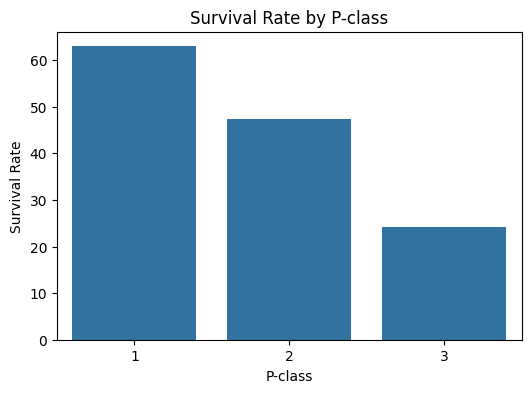

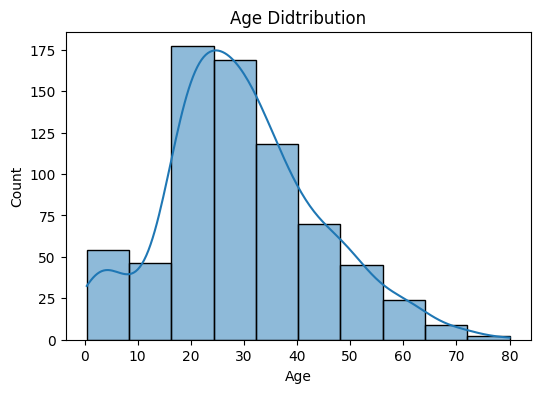

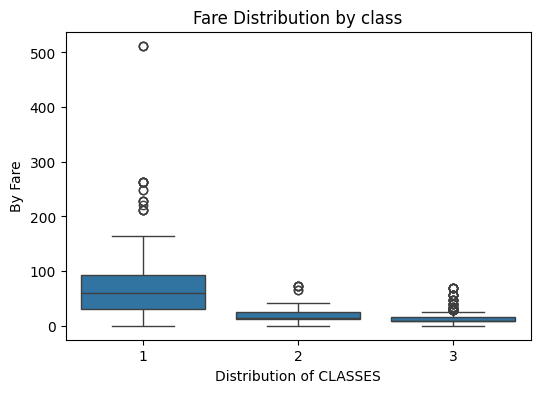

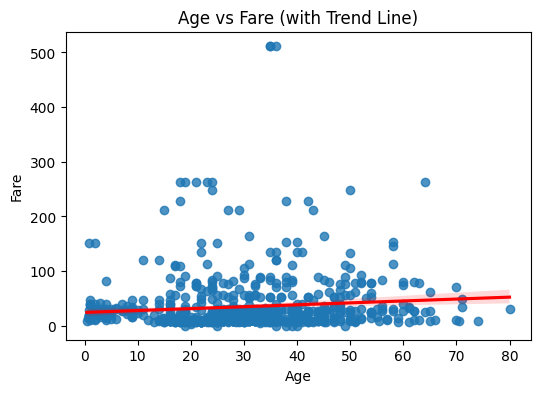

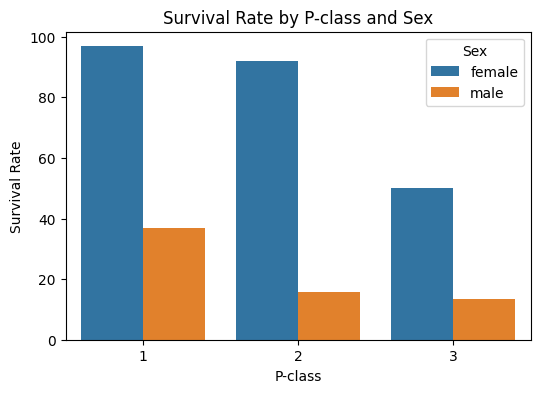

In [26]:
print(df.dtypes)
data=df.groupby('Pclass')['Survived'].mean()*100
data
plt.figure(figsize=(6, 4))
sns.barplot(data)
plt.title('Survival Rate by P-class')
plt.xlabel('P-class')
plt.ylabel('Survival Rate')
plt.show()

# Chart 2:
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'],bins=10,kde=True)
plt.title('Age Didtribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Chart 3:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Pclass',y='Fare',data=df)
plt.xlabel('Distribution of CLASSES')
plt.ylabel('By Fare')
plt.title('Fare Distribution by class')
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Chart 4:
plt.figure(figsize=(6, 4))
sns.regplot(x="Age", y="Fare", data=df, line_kws={"color": "red"})
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare (with Trend Line)")
plt.show()

data_b=df.groupby(['Pclass','Sex'])['Survived'].mean()*100
data_b=data_b.round(1).reset_index()
# Chart
plt.figure(figsize=(6, 4))
sns.barplot(data=data_b, x="Pclass", y="Survived", hue="Sex")

plt.xlabel('P-class')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by P-class and Sex')
plt.show()



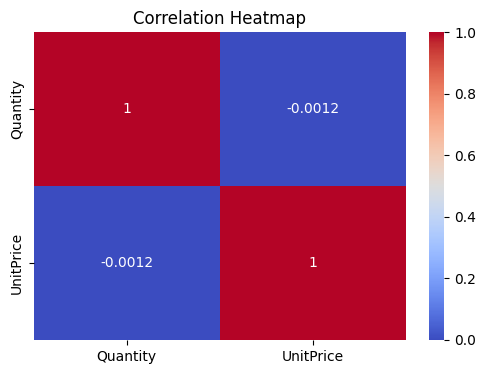

LEVEL 2
CustomerID  Country       
14646.0     Netherlands       279489.0
18102.0     United Kingdom    256438.5
17450.0     United Kingdom    187482.2
14911.0     EIRE              132572.6
12415.0     Australia         123725.4
Name: Total_Price, dtype: float64
LEVEL 3
OUTLIER DETECTION


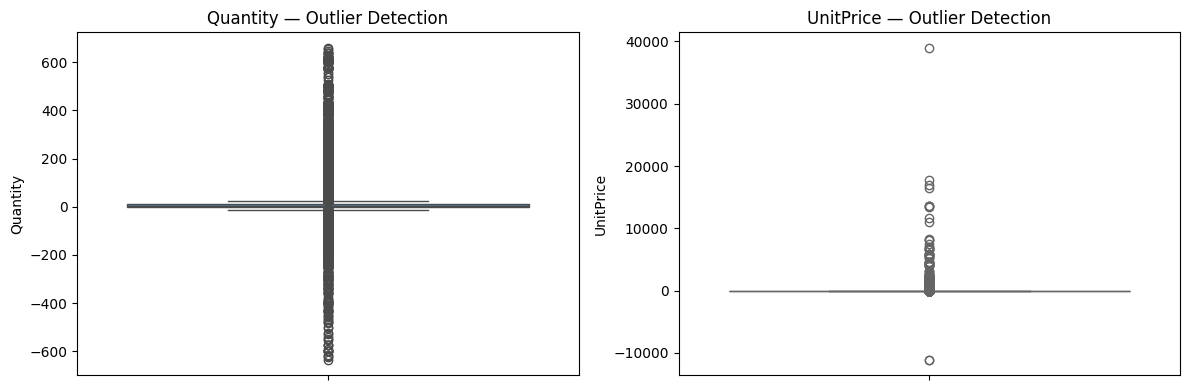

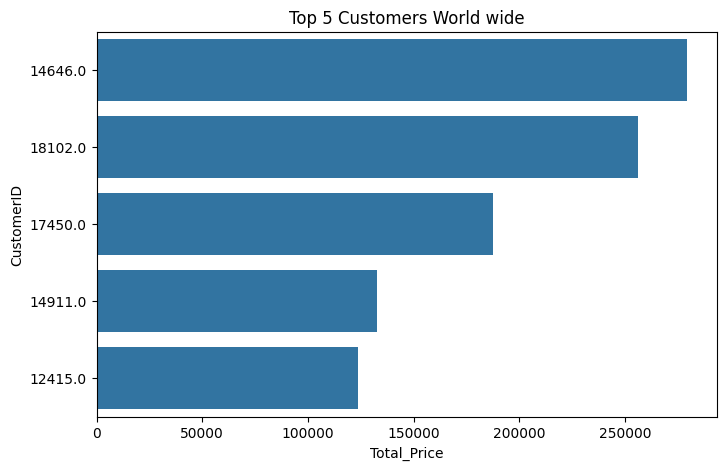

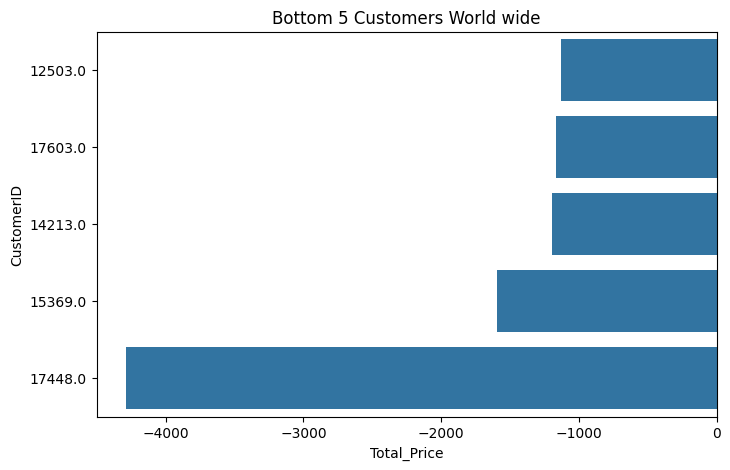

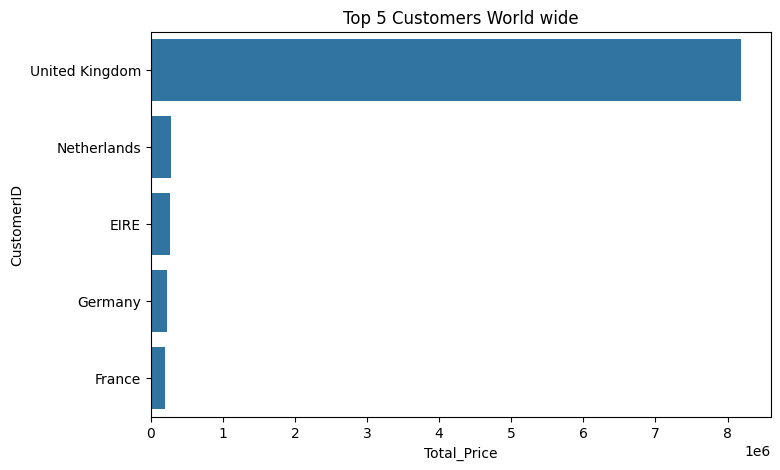

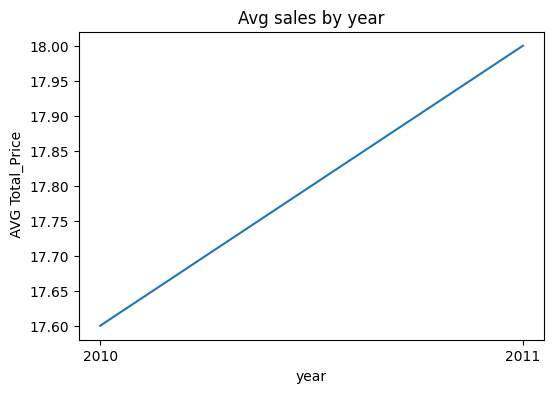

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price,year,quantity_z
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0,2010,0.212984
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0,2010,0.039216
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0,2010,0.039216
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0,2010,0.039216
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0,2010,0.039216


In [51]:
from numpy._core import numeric
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# step 1
df=pd.read_csv('data.csv',encoding='latin1')
# step 2:
df.shape
# (541909, 8) long format data

# df.info()
missing_data=df.isnull().sum()

# after watching the .head() get to know data is already (exploded) by invoice number and the Customer Id
# percentage of missing data
percentage_missing_data=(missing_data/len(df))*100
percentage_missing_data
# description is 0.2 and may be system error or receptionist did't add thar or can be serious error: price and quantity without description
# left description as it is and customer as it
# now CustomerID	has 24.926694 missing and can't fill this id by any mean or can't use median for the system generated id's

# Step3:
df.describe() #got min price and quantity in negative later work on it in data drilling
# mean of unit price is 4 it's std is 96 means data is spread alot
# Step 4:
df['CustomerID']=df['CustomerID'].astype(object) # removing customer id

corr_data=df.corr(numeric_only=True)
corr_data
# heat map
plt.figure(figsize=(6, 4))
sns.heatmap(corr_data, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show() #no relation was strong even in negative or positive (all relations are very weak)

# step 5: data drilling :
df['Total_Price']=df['Quantity']*df['UnitPrice']
# step 5.1 total purchace by all customers top data hierarchial level(1)
data_by_all=df.groupby('CustomerID')['Total_Price'].sum().round(1)
data_by_all = data_by_all.sort_values(ascending=False,)
data_by_all.head()

# 5.2 by also countries hierarchial level(2)
data_by_all_country=df.groupby(['CustomerID','Country'])['Total_Price'].sum().round(1)
data_by_all_country = data_by_all_country.sort_values(ascending=False,)
print("LEVEL 2")
print(data_by_all_country.head())


# 5.3 date is freater then after 2023
# here i can also just filter the whole data frame where date greater then 2023 hierarchial level(3) bottom
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'],format='mixed')
df['year']=df['InvoiceDate'].dt.year
df_filtered=df[df['year']>=2023]
df_fil_data=df_filtered.groupby(['CustomerID','Country'])['Total_Price'].sum().round(1)
df_fil_data = df_fil_data.sort_values(ascending=False,)
print("LEVEL 3")
df_fil_data.head() # my question :was my data drilling was perfect or logically correct?


# step 6: using z-score only for the quantity column and box plot for 2 attributes
print('=========')
print('OUTLIER DETECTION')
print('=========')

df['quantity_z']=np.abs(stats.zscore(df['Quantity']))
df['quantity_z']

# replacing with median which is the best thing near me instead of removing them
df.loc[df['quantity_z']>3.0,'Quantity']=df['Quantity'].median()
# box plot outliers detection
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'], color='steelblue')
plt.title('Quantity — Outlier Detection')
# got shoked the quantity is also going in the -ve values and have thousand or lackhs of outliers i think the quantity attri was not good for the box plot i can have real unsual cases but still -ve values is shoking me
# even i cleaned it with the z score (quantity column with the median but still outliers)
plt.subplot(1, 2, 2)
sns.boxplot(y=df['UnitPrice'], color='coral')
plt.title('UnitPrice — Outlier Detection')

plt.tight_layout()
plt.show()
# the 2nd box plot is still very strange and don't know why showing outliers in the -10000 and 40000

# now combining the 7 and 9 task making atleast 5 graphs.
# by my own mind like which graph's or data must be visualize here from this dataframe
# graph one (top customer world wide from our malls or shops)
df_total=df.groupby('CustomerID')['Total_Price'].sum().reset_index()
df_total=df_total.sort_values('Total_Price',ascending=False).round(1)
top_5=df_total.head()
plt.figure(figsize=(8,5))
sns.barplot(data=top_5,x='Total_Price',y=top_5['CustomerID'].astype(str))
plt.xlabel('Total_Price')
plt.ylabel('CustomerID')
plt.title('Top 5 Customers World wide')
plt.show()

b_5=df_total.tail()


# bottom 5 customers from world wide
plt.figure(figsize=(8,5))
sns.barplot(data=b_5,x='Total_Price',y=b_5['CustomerID'].astype(str))
plt.xlabel('Total_Price')
plt.ylabel('CustomerID')
plt.title('Bottom 5 Customers World wide')
plt.show() # bottom customer's data is from right to left means in -ve i don't why


# chart 3: top 5 countries
df_total=df.groupby('Country')['Total_Price'].sum().reset_index()
df_total=df_total.sort_values('Total_Price',ascending=False).round(1)
top_con=df_total.head()
plt.figure(figsize=(8,5))
sns.barplot(data=top_con,x='Total_Price',y=top_con['Country'].astype(str))
plt.xlabel('Total_Price')
plt.ylabel('CustomerID')
plt.title('Top 5 Customers World wide')
plt.show() # uK's data is in le6 in almost 9 so ithink i become 9000,000 9 million

df['year']=df['year'].astype(str)
data_year=df.groupby('year')['Total_Price'].mean().reset_index()
data_year=data_year.sort_values('year',ascending=True).round(1)
data_year
df['year'].unique() # has only 2 years 2010 2011 but i know its not god for this only 2 years
# chart 4: avg sales by year:
plt.figure(figsize=(6,4))
sns.lineplot(data=data_year,x='year',y='Total_Price')
plt.xlabel('year')
plt.ylabel(' AVG Total_Price')
plt.title('Avg sales by year')
plt.show()

# chart 5:
# plt.figure(figsize=(6,4))
# sns.regplot(data=df,x='Quantity',y='UnitPrice',ci=None,line_kws={'color': 'red'})
# plt.xlabel('Quantity')
# plt.ylabel('UnitPrice')
# plt.title('Quantity vs UnitPrice')
# plt.show() # just got a flat horizontal line no relationship

# task 8 data mining finding treand or patterns and applying the anomalies
# finding rare values my brain login was: having atleast 1 quantity and the total price is 0 or less then 0
df_logical_rare=df[(df['Quantity']>=1) &  (df['Total_Price']<=0)]
df_logical_rare.head()
# print(len(df_logical_rare)) # got 1271 row's don't know why this happened because there wear no discount coupn attribute hoe total can be zero
# just got there unit price was 0 don't know how price of some thing can be 0

# directly droping the duplicates instead of first noticing them and then droping just for short
# df_cleaned=df.drop_duplicates()


## ***Super Store Data***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

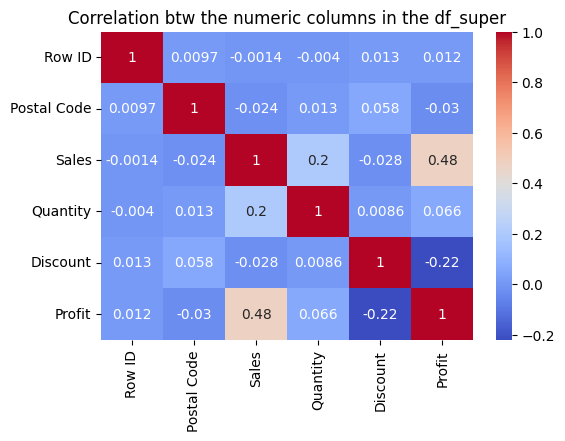

discount by the whole customers world wide
Customer ID
ZC-21910    7.9
WB-21850    7.6
EA-14035    7.5
CK-12205    7.5
LC-16870    7.2
Name: Discount, dtype: float64
Region
Central    0.24
East       0.15
South      0.15
West       0.11
Name: Discount, dtype: float64
# by the region and the category
Replaced


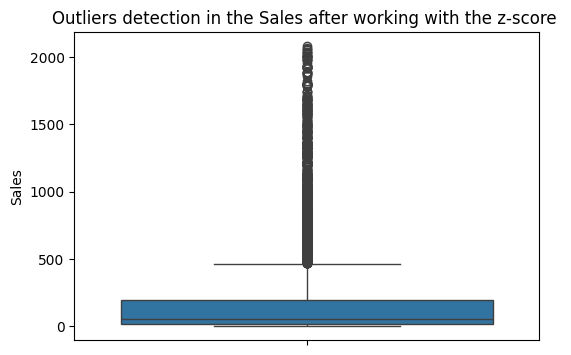

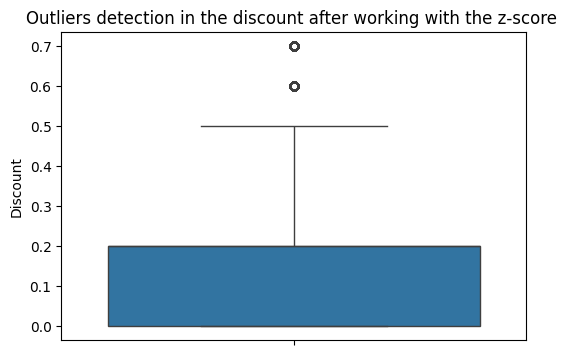

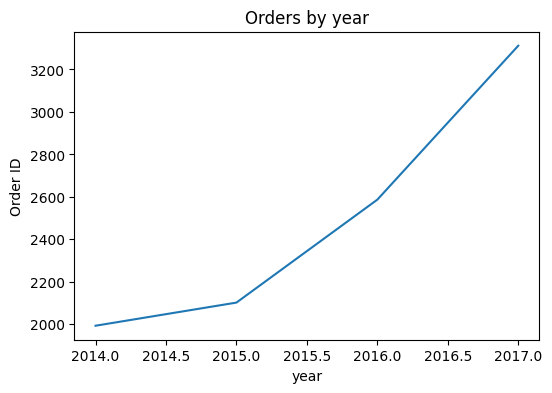

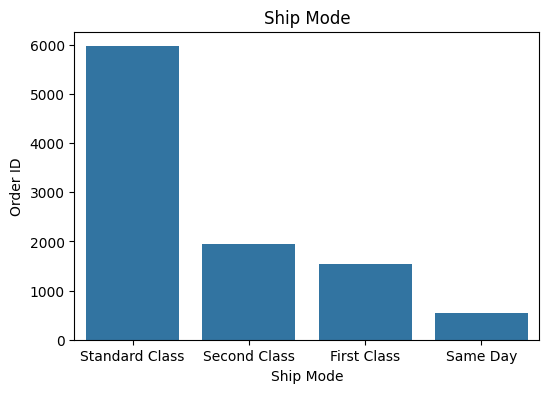

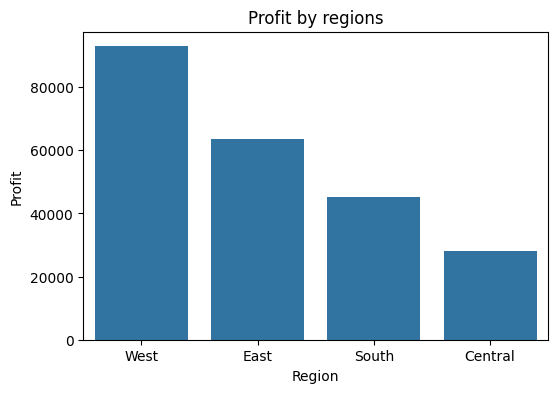

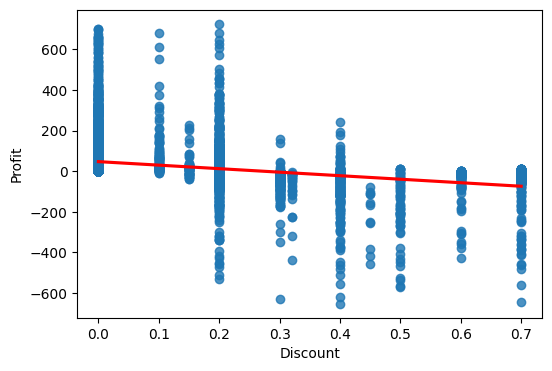

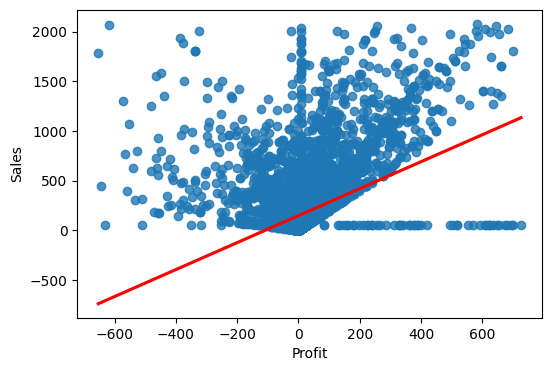

1834
Max dis
0.7
min discount
0.1
min profit


In [63]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# step 1 loaded
df_super=pd.read_csv('Sample - Superstore.csv',encoding='latin1')
# step 2
df_super.shape #got 9994 and 12 attributes means can't say it's only long format data (a wide format data)
df_super.info() # after watching the info it seems that every column type is perfect no need the type conversion of any column
df_super.isnull().sum() # data is completely filled no need to add or fill or drop the values

# step 3:
df_super.describe() # the mean and the std is telling the data is spread and the min profit is in -ve means we got some loss at some records(find it in later steps)
# and the good thing was the max discount is 0.800000(means that -ve prifit's reason can be some other)(i will find it)
# Step 4 correlations
# through heat map
plt.figure(figsize=(6,4))
sns.heatmap(df_super.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title('Correlation btw the numeric columns in the df_super')
plt.show()
# 2 airs i would like to mention here
# 1=sales and the profit 0.48(corr value) means the increase in sales increase in the profit (very normal +ve relation)
# 2.discount vs profit =increase in discount decrease in the profit(-0.22) some little -ve relation

# Step 5: data drilling analyzing the hierarchial levels of the data
# 5.1 discount by the whole customers world wide
big_discount=df_super.groupby('Customer ID')['Discount'].sum().round(2)
big_discount=big_discount.sort_values(ascending=False)
print('discount by the whole customers world wide')
print(big_discount.head())
# max discount to "ZC-21910" upto 7.9 percent whole

# 5.2 avg of the discount to region
discount_by_region=df_super.groupby('Region')['Discount'].mean().round(2)
discount_by_region=discount_by_region.sort_values(ascending=False)
print(discount_by_region) # central region is 0.24percent


# 5.3 by the region and the category
df_data=df_super.groupby(['Region','Category'])['Discount'].max().sort_values(ascending=False).round(2)
df_data=df_data.reset_index()
print("# by the region and the category")
df_data.head() #central and furniture got the 0.30 avg discount

# Step 6: outliers
# we just have 3-4 numeric attributes and 2-3 columns will be make sence for finding the outliers like sales and the profit (not the row id or the customer ID or the postal code these are also int or float)
df_super['sales_z']=np.abs(stats.zscore(df_super['Sales']))
df_super['profit_z']=np.abs(stats.zscore(df_super['Profit']))
df_super['discount_z']=np.abs(stats.zscore(df_super['Discount']))
# as told you replacing is much better then driping so
df_super.loc[df_super['sales_z']>3,'Sales']=df_super['Sales'].median()
df_super.loc[df_super['profit_z']>3,'Profit']=df_super['Profit'].median()
df_super.loc[df_super['discount_z']>3,'Discount']=df_super['Discount'].median()
print('Replaced')

# now using box plots for them
plt.figure(figsize=(6,4))
sns.boxplot(y=df_super['Sales'])
plt.title('Outliers detection in the Sales after working with the z-score ')
plt.show() # very bad graph even after replacing some time i dont belif that z- score and .loc really replave them wit the median very dirty
# grapg according to the boxplot the maz wisker is on 500 and the dots are going upto 2000 i don't know after replacing how it can reach these levels in the outliers

plt.figure(figsize=(6,4))
sns.boxplot(y=df_super['Discount'])
plt.title('Outliers detection in the discount after working with the z-score ')
plt.show()
# some thing better got 3 dots the max is 0.5 and these 3 are 0.6 ,0.7 and 0.8 but still after replacing with the median i am watching outliers disapointing

# combine task 7 and 9  making visuals according to my mind and trying my best to add the plot that must fit here or which data must be visualize or must higlight and which insights must require the visuals to release the hidden pttern

# plot 1
# which year got max order's
df_super['Order Date']=pd.to_datetime(df_super['Order Date'],format='mixed')
df_super['year']=df_super['Order Date'].dt.year
df_super['year'].unique()
# i think the bar plot is best for this but just making the line plot
df_data_year=df_super.groupby('year')['Order ID'].count().reset_index()
df_data_year=df_data_year.sort_values('year',ascending=True).round(1)
df_data_year
plt.figure(figsize=(6,4))
sns.lineplot(data=df_data_year,x='year',y='Order ID')
plt.xlabel('year')
plt.ylabel('Order ID')
plt.title('Orders by year')
plt.show() # from the 2014 to 2017 orders are increasing no downfall


# plot 2:
# which ship mode is mostly using
df_data_ship=df_super.groupby('Ship Mode')['Order ID'].count().reset_index()
df_data_ship=df_data_ship.sort_values('Order ID',ascending=False).round(1)
df_data_ship

plt.figure(figsize=(6,4))
sns.barplot(data=df_data_ship,x='Ship Mode',y='Order ID')
plt.xlabel('Ship Mode')
plt.ylabel('Order ID')
plt.title('Ship Mode')
plt.show()
# standard class by 6000(max) and the lowest almost same day mode550 to 700 (lowest )
# and by the way i dont know what is this ship mode is by ship or the plan?
# but form the name i got (same day mode)very low because it is expensive and use the standard because it is cheap

# plot 3:
# total profit of every region (i have done total_sales by the country in the previous task so not using country)
df_profit=df_super.groupby('Region')['Profit'].sum().reset_index().round(2)
df_profit=df_profit.sort_values('Profit',ascending=False).round(1)
df_profit
plt.figure(figsize=(6,4))
sns.barplot(data=df_profit,x='Region',y='Profit')
plt.title('Profit by regions')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()
# west region is on top and the central region is last but at the top of giving the discounts and thats the reason

# plot 4: discount vs profit
plt.figure(figsize=(6,4))
sns.regplot(data=df_super,x='Discount',y='Profit',ci=None,line_kws={'color': 'red'})
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()#not much down line its corr was also -0.2 i guess

# plot 5:
plt.figure(figsize=(6,4))
sns.regplot(data=df_super,x='Profit',y='Sales',ci=None,line_kws={'color': 'red'})
plt.xlabel('Profit')
plt.ylabel('Sales')
plt.show() #the dots are only in the positive part but the reg red line is starting from the negaive left botom to the positive right top but still if i see the dots attern its some how a positive relation as its corr was 0.48 i guess



# task 8:
# data mining now here going to work on the thing i fount in the df_super.describe() profit in the negative what is it is it rare or is it some thing mismanagement by us
df_rare=df_super[df_super['Profit']<0]
print(len(df_rare)) # got 1834 reords with the -ve in profit
df_rare['Category'].mode() # most category is office supplies
df_rare['Sub-Category'].mode() # most Sub-Category is binders
df_rare['Discount'].mean() # 0.4
df_rare['Discount'].median() # also 0.4 means mean == median which is good means the discounts are reals not outliers affected
# df_rare['Discount'].std()  #0.235 data is little spread not much
print('Max dis')
print(df_rare['Discount'].max()) #0.8

print('min discount')
print(df_rare['Discount'].min()) #0.1


print('min profit')
min_profit_row = df_super.loc[df_super["Profit"].idxmin()]
min_profit_row
# its discount was 0.4 on the table in furniture category (but sadly still i am unable to find the exect reason behind this in the south region)

# now just removing the duplicates sadly after not getting the reason of this -ve
df_super=df_super.drop_duplicates()

